# Credit Scoring Audit — figure workbench

The regulation names a **prohibited exemplar** `P_bad` (a scorer that uses the
protected attribute, fitted to biased lending history) and bans it together with
every diluted version of it:

`P_0 = { alpha * P_bad + (1 - alpha) * U : alpha in [alpha_min, 1] }`

A segment between two points is closed and convex, so this is a credal set by
construction. A provider cannot escape by randomising between the banned scorer
and a coin flip — every such mixture is itself in `P_0`.

Licence: `pi_n = min(C * prod q_user / p*, R)`, flat at `C` during calibration.

In [1]:
!pip install ucimlrepo numpy pandas scipy scikit-learn matplotlib SciencePlots

DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_thunder-0.2.0.dev0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/opt_einsum-3.4.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_utilities-0.12.0.dev0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/nvfuser-0.2.23a0+6627725-py3.12-linux-x86_64

In [2]:
import os, sys, argparse, pickle
import numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, ".")
import data as data_mod, providers as prov_mod, betting
try:
    import scienceplots  # noqa: F401
    plt.style.use(["science", "no-latex"])
except Exception:
    plt.style.use("default")
%load_ext autoreload
%autoreload 2

## 1. Configuration

In [3]:
CFG = dict(
    dataset   = "german",              # "german" | "taiwan" | "synth"
    T         = 501,                   # audited applicants per run
    runs      = 30,                    # independent audits
    cal_frac  = 0.2,                   # burn-in share (licence held at C)
    bias      = 0.8,                   # historical bias, TRAINING splits only
    alpha_min = betting.ALPHA_MIN,     # most-diluted member of the segment
    eps       = betting.EPS_SMOOTH,
    gammas    = [1.0, 0.9, 0.8, 0.7, 0.6],   # dilution levels to audit
    C = 15.0, R = 250.0, seed = 0, strict = False,
)
ARGS = argparse.Namespace(**CFG)
OUTDIR = "figures"; os.makedirs(OUTDIR, exist_ok=True)
SPLIT = max(int(ARGS.T * ARGS.cal_frac), 10)
CFG

{'dataset': 'german',
 'T': 501,
 'runs': 30,
 'cal_frac': 0.2,
 'bias': 0.8,
 'alpha_min': 0.5,
 'eps': 0.01,
 'gammas': [1.0, 0.9, 0.8, 0.7, 0.6],
 'C': 15.0,
 'R': 250.0,
 'seed': 0,
 'strict': False}

### Data source check

In [4]:
data_mod.diagnose()
# ucimlrepo missing? install it, then RESTART THE KERNEL.
# Set CFG['strict']=True for paper figures so a silent fallback cannot happen.

--- credit_scoring data diagnostics ---
ucimlrepo   : installed (v?)
taiwan      : ok, n=30000, columns[:8]=['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']
german      : ok, n=1000, columns[:8]=['Attribute1', 'Attribute2', 'Attribute3', 'Attribute4', 'Attribute5', 'Attribute6', 'Attribute7', 'Attribute8']


## 2. Build the world: regulator's exemplar + both providers

In [5]:
rng = np.random.default_rng(ARGS.seed)
X, a, y = data_mod.load(ARGS.dataset, strict=ARGS.strict)
W = prov_mod.fit_world(X, a, y, seed=ARGS.seed, bias=ARGS.bias)
m = W.meta

print(f"splits   regulator {m['n_reg']} (biased -> {m['n_reg_biased']}), "
      f"providers {m['n_prov']} (biased -> {m['n_prov_biased']}), "
      f"audit {m['n_audit']}")
print(f"A-coeff  P_bad {m['coef_a_bad']:+.3f}   uses_A {m['coef_a_uses']:+.3f}")
print(f"log-lik  P_bad {m['loglik_bad']:+.4f}   uses_A {m['loglik_uses']:+.4f}"
      f"   blind {m['loglik_blind']:+.4f}")
print(f"P_0      alpha in [{ARGS.alpha_min}, 1];  C={ARGS.C}, R={ARGS.R}")

[data] loaded german: n=1000, d=45, P(a=1)=0.310, P(y=1)=0.700
splits   regulator 333 (biased -> 187), providers 333 (biased -> 169), audit 334
A-coeff  P_bad +1.306   uses_A +2.114
log-lik  P_bad -0.9113   uses_A -1.0760   blind -0.5769
P_0      alpha in [0.5, 1];  C=15.0, R=250.0


## 3. Run the audits

`blind` and `uses_A` are the two providers; the rest are `P_bad` diluted at each
`gamma` — the mixing attack. Every dilution should self-exclude.

In [6]:
panel = [("blind (compliant)", W.p_blind, True),
         ("uses_A (non-compliant)", W.p_uses, False)]
for g in ARGS.gammas:
    tag = "P_bad itself" if g == 1.0 else f"P_bad diluted gamma={g:g}"
    panel.append((tag, prov_mod.dilute(W.p_bad, g), False))

trajectories, rows = {}, []
print(f"{'provider':<28s}{'alpha*':>8s}{'licence':>10s}{'SE':>8s}{'part':>7s}   verdict")
for name, p_user, compliant in panel:
    traj, lic, part, alphas = betting.run_audits(
        p_user, W.p_bad, W.y, T=ARGS.T, n_runs=ARGS.runs, rng=rng,
        C=ARGS.C, R=ARGS.R, eps=ARGS.eps, cal_frac=ARGS.cal_frac,
        alpha_min=ARGS.alpha_min)
    trajectories[name] = traj
    se = lic.std(ddof=1) / np.sqrt(len(lic))
    ok = (part.mean() > 0.5) == compliant
    rows.append(dict(provider=name, compliant=compliant,
                     alpha_star=float(alphas.mean()),
                     licence_mean=float(lic.mean()), licence_se=float(se),
                     participation_rate=float(part.mean()), pmo_correct=bool(ok)))
    v = "PARTICIPATES" if part.mean() > 0.5 else "SELF-EXCLUDES"
    print(f"{'ok ' if ok else 'XX '}{name:<25s}{alphas.mean():>8.3f}"
          f"{lic.mean():>10.2f}{se:>8.2f}{part.mean():>7.2f}   {v}")

summary = pd.DataFrame(rows)
print(f"\n-> PMO achieved: {bool(summary['pmo_correct'].all())}")
summary

provider                      alpha*   licence      SE   part   verdict
ok blind (compliant)           0.548    243.41    6.59   1.00   PARTICIPATES
ok uses_A (non-compliant)      0.534      0.00    0.00   0.00   SELF-EXCLUDES
ok P_bad itself                1.000     15.00    0.00   0.00   SELF-EXCLUDES
ok P_bad diluted gamma=0.9     0.900     15.00    0.00   0.00   SELF-EXCLUDES
ok P_bad diluted gamma=0.8     0.800     15.00    0.00   0.00   SELF-EXCLUDES
ok P_bad diluted gamma=0.7     0.700     15.00    0.00   0.00   SELF-EXCLUDES
ok P_bad diluted gamma=0.6     0.600     15.00    0.00   0.00   SELF-EXCLUDES

-> PMO achieved: True


,provider,compliant,alpha_star,licence_mean,licence_se,participation_rate,pmo_correct
0,blind (compliant),True,0.548197,243.409586,6.590414e+00,1.0,True
1,uses_A (non-compliant),False,0.534486,0.000000,0.000000e+00,0.0,True
2,P_bad itself,False,1.000000,14.999606,1.280866e-05,0.0,True
3,P_bad diluted gamma=0.9,False,0.900000,15.000011,1.170771e-06,0.0,True
4,P_bad diluted gamma=0.8,False,0.800000,15.000000,1.606059e-06,0.0,True
5,P_bad diluted gamma=0.7,False,0.700000,15.000000,1.302155e-07,0.0,True
6,P_bad diluted gamma=0.6,False,0.600000,15.000000,3.492522e-08,0.0,True


## 4. Figure — tweak freely and re-run this cell alone

Bands are mean +/- 1 standard error across audit runs (ddof=1). The calibration
phase is drawn faded: the licence is held at `C` while the regulator picks its
null, and only moves once the audit proper begins.

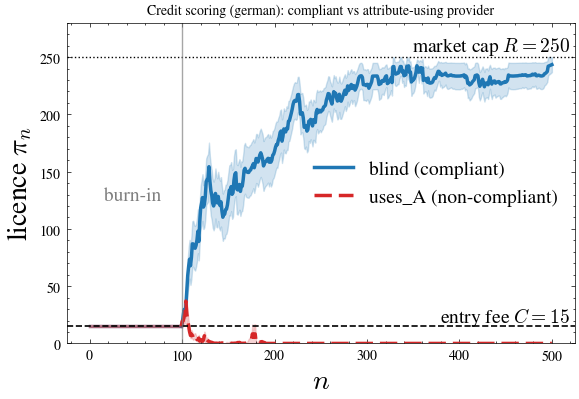

bands = mean +/- 1 SE across 30 audit runs


In [7]:
# ------------------------- tweak here -------------------------
PLOT_ONLY = ("blind", "uses_A")   # dilutions stay in the table, off the figure
FIGSIZE   = (6.0, 4.2)
YLIM      = (0, ARGS.R * 1.12)
LEGEND_FS = 8
SAVE      = True
def style(name):
    if name.startswith("blind"):  return "tab:blue", "-"
    if name.startswith("uses_A"): return "tab:red",  (0, (5, 2))
    return "tab:orange", (0, (3, 1, 1, 1))
# --------------------------------------------------------------

fig, ax = plt.subplots(figsize=FIGSIZE)
for name, traj in trajectories.items():
    if PLOT_ONLY and not name.startswith(PLOT_ONLY):
        continue
    c, ls = style(name)
    betting.plot_licence(ax, traj, label=name, color=c, split=SPLIT, ls=ls)

ax.axhline(ARGS.C, color="k", ls="--", lw=1.2)
ax.axhline(ARGS.R, color="k", ls=":", lw=1.0)
ax.axvline(SPLIT, color="gray", lw=1.0, alpha=0.7)
ax.text(0.1 * SPLIT, ARGS.R * 0.5, " burn-in", fontsize=14, color="gray")
ax.set_ylim(*YLIM)
ax.set_xlabel("$n$", fontsize=20)
ax.set_ylabel(r"licence $\pi_n$", fontsize=20)
ax.set_title(f"Credit scoring ({ARGS.dataset}): compliant vs attribute-using provider",
             fontsize=10)
ax.text(0.99, ARGS.C * 1.25, "entry fee $C=15$", fontsize=14, ha="right",
        transform=ax.get_yaxis_transform())
ax.text(0.99, ARGS.R * 1.02, "market cap $R=250$", fontsize=14, ha="right",
        transform=ax.get_yaxis_transform())
ax.legend(fontsize=14, loc="center right")
fig.tight_layout()
if SAVE:
    for ext in ("pdf", "png"):
        fig.savefig(f"{OUTDIR}/credit_{ARGS.dataset}_licence.{ext}",
                    dpi=200, bbox_inches="tight")
plt.show()
print(f"bands = mean +/- 1 SE across {ARGS.runs} audit runs")


In [8]:
import numpy as np, pandas as pd

NS = [0, 100, 150, 200, 300, 400, 500]      # n values for the table columns
who = ["blind (compliant)", "uses_A (non-compliant)"]

rows = []
for name in who:
    A = trajectories[name]                   # shape (runs, T+1)
    ns = [n for n in NS if n < A.shape[1]]
    r = {"provider": name}
    for n in ns:
        se = A[:, n].std(ddof=1) / np.sqrt(A.shape[0])
        r[f"n={n}"] = f"{A[:, n].mean():.2f} ± {se:.2f}"
    rows.append(r)

tab = pd.DataFrame(rows).set_index("provider")
print(tab.to_string())
print(tab.to_latex())        # or tab.to_markdown()

                                 n=0         n=100           n=150           n=200           n=300           n=400          n=500
provider                                                                                                                         
blind (compliant)       15.00 ± 0.00  17.40 ± 2.40  127.57 ± 21.66  167.92 ± 20.59  226.22 ± 13.29  233.38 ± 11.55  243.41 ± 6.59
uses_A (non-compliant)  15.00 ± 0.00  19.15 ± 2.25     0.71 ± 0.53     0.00 ± 0.00     0.00 ± 0.00     0.00 ± 0.00    0.00 ± 0.00
\begin{tabular}{llllllll}
\toprule
 & n=0 & n=100 & n=150 & n=200 & n=300 & n=400 & n=500 \\
provider &  &  &  &  &  &  &  \\
\midrule
blind (compliant) & 15.00 ± 0.00 & 17.40 ± 2.40 & 127.57 ± 21.66 & 167.92 ± 20.59 & 226.22 ± 13.29 & 233.38 ± 11.55 & 243.41 ± 6.59 \\
uses_A (non-compliant) & 15.00 ± 0.00 & 19.15 ± 2.25 & 0.71 ± 0.53 & 0.00 ± 0.00 & 0.00 ± 0.00 & 0.00 ± 0.00 & 0.00 ± 0.00 \\
\bottomrule
\end{tabular}

